In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "divvy-tripdata"           "divvy-tripdata-2024-2025"

# Project Overview

This project focus on analyze the previous 12 months of Cyclist trip data. The main goal of this analysis is help Cyclistic-a bike share company- to increase the number of annual merbers by producing a specific marketing strategy to convert casual in annual members. 
For this purpose, this analysis will indentify how annual members and casual riders use Cyclistic bikes dierently and use this insights to produce three key recommendation for a better marketing strategy. 

## Prepare 

The first step will be create a dataset with the **divvy-tripdata**, a public dataset with the data needed for this project. To make easier manipulate the data, I will combine all files (from 03/2024 to 03/2025) in one dataframe. 

In [2]:
library(tidyverse)

# List all CSV files in the input folder and its subfolders
file_paths <- list.files(path = "../input/divvy-tripdata-2024-2025", 
                         pattern = "*.csv", 
                         recursive = TRUE, 
                         full.names = TRUE)

# Read all CSV files and combine into one dataframe
all_data <- file_paths %>%
  map_df(read_csv)


Rows: 301687 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ride_id, rideable_type, start_station_name, start_station_id, end_...
dbl  (4): start_lat, start_lng, end_lat, end_lng
dttm (2): started_at, ended_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 415025 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ride_id, rideable_type, start_station_name, start_station_id, end_...
dbl  (4): start_lat, start_lng, end_lat, end_lng
dttm (2): started_at, ended_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 609493 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7

In [3]:
## I will filter the dataset to maintain just the data I will use in the analysis
all_data <- all_data %>%
select(rideable_type,started_at,ended_at,member_casual)
glimpse(all_data)

Rows: 6,081,255
Columns: 4
$ rideable_type <chr> "electric_bike", "electric_bike", "electric_bike", "elec…
$ started_at    <dttm> 2024-03-05 18:33:11, 2024-03-06 17:15:14, 2024-03-06 17…
$ ended_at      <dttm> 2024-03-05 18:51:48, 2024-03-06 17:16:04, 2024-03-06 17…
$ member_casual <chr> "member", "member", "member", "member", "member", "membe…


## Process

The colunms with nulls already were eliminate, to complete the cleaning process I will separate the colunms with Date-Time and adjust them to a properly format.

In [4]:
all_data <- all_data %>%
mutate(
     StartDate = as.Date(started_at),
    StartTime = format(started_at, "%H:%M:%S"),
    EndedDate= as.Date(started_at),
    EndedTime = format(ended_at,"%H:%M:%S")
  ) 
head(all_data)

rideable_type,started_at,ended_at,member_casual,StartDate,StartTime,EndedDate,EndedTime
<chr>,<dttm>,<dttm>,<chr>,<date>,<chr>,<date>,<chr>
electric_bike,2024-03-05 18:33:11,2024-03-05 18:51:48,member,2024-03-05,18:33:11,2024-03-05,18:51:48
electric_bike,2024-03-06 17:15:14,2024-03-06 17:16:04,member,2024-03-06,17:15:14,2024-03-06,17:16:04
electric_bike,2024-03-06 17:16:36,2024-03-06 17:19:28,member,2024-03-06,17:16:36,2024-03-06,17:19:28
electric_bike,2024-03-03 22:55:54,2024-03-03 22:58:08,member,2024-03-03,22:55:54,2024-03-03,22:58:08
electric_bike,2024-03-17 11:15:18,2024-03-17 11:31:18,member,2024-03-17,11:15:18,2024-03-17,11:31:18
electric_bike,2024-03-29 14:40:49,2024-03-29 14:58:11,member,2024-03-29,14:40:49,2024-03-29,14:58:11


In [5]:
all_data <- all_data %>%
  select(-started_at, -ended_at)


## Analyze  

1. **Ride Length**

The first analysis will be determine the ride length acording to the user, for do this I will transform the start and ended time in minutes and then calculate the difference between them to measure the duration of each ride.

In [6]:
all_data$StartMinutes <- as.numeric(as.difftime(all_data$StartTime, format = "%H:%M:%S", units = "mins"))
all_data$EndedMinutes <- as.numeric(as.difftime(all_data$EndedTime, format = "%H:%M:%S", units = "mins"))

In [7]:
all_data <- all_data %>%
mutate(RideLength= ifelse(
    StartMinutes>EndedMinutes,
    (EndedMinutes+1440)- StartMinutes,
       EndedMinutes - StartMinutes ) )
       



In [8]:
all_data$RideLength <- round(all_data$RideLength, 2)
head(all_data)

rideable_type,member_casual,StartDate,StartTime,EndedDate,EndedTime,StartMinutes,EndedMinutes,RideLength
<chr>,<chr>,<date>,<chr>,<date>,<chr>,<dbl>,<dbl>,<dbl>
electric_bike,member,2024-03-05,18:33:11,2024-03-05,18:51:48,1113.1833,1131.8000,18.62
electric_bike,member,2024-03-06,17:15:14,2024-03-06,17:16:04,1035.2333,1036.0667,0.83
electric_bike,member,2024-03-06,17:16:36,2024-03-06,17:19:28,1036.6000,1039.4667,2.87
electric_bike,member,2024-03-03,22:55:54,2024-03-03,22:58:08,1375.9000,1378.1333,2.23
electric_bike,member,2024-03-17,11:15:18,2024-03-17,11:31:18,675.3000,691.3000,16.00
electric_bike,member,2024-03-29,14:40:49,2024-03-29,14:58:11,880.8167,898.1833,17.37


In [9]:
annual_member_data <- all_data %>%
filter(member_casual== "member")
summary(annual_member_data)

 rideable_type      member_casual        StartDate           StartTime        
 Length:3863444     Length:3863444     Min.   :2024-03-01   Length:3863444    
 Class :character   Class :character   1st Qu.:2024-06-07   Class :character  
 Mode  :character   Mode  :character   Median :2024-08-15   Mode  :character  
                                       Mean   :2024-08-21                     
                                       3rd Qu.:2024-10-21                     
                                       Max.   :2025-03-31                     
   EndedDate           EndedTime          StartMinutes     EndedMinutes   
 Min.   :2024-03-01   Length:3863444     Min.   :   0.0   Min.   :   0.0  
 1st Qu.:2024-06-07   Class :character   1st Qu.: 630.3   1st Qu.: 638.5  
 Median :2024-08-15   Mode  :character   Median : 914.6   Median : 924.5  
 Mean   :2024-08-21                      Mean   : 862.0   Mean   : 870.5  
 3rd Qu.:2024-10-21                      3rd Qu.:1079.3   3rd Qu.:1090.5

In [10]:
casual_member_data <- all_data %>%
filter(member_casual== "casual")
summary(casual_member_data)

 rideable_type      member_casual        StartDate           StartTime        
 Length:2217811     Length:2217811     Min.   :2024-03-01   Length:2217811    
 Class :character   Class :character   1st Qu.:2024-06-13   Class :character  
 Mode  :character   Mode  :character   Median :2024-08-04   Mode  :character  
                                       Mean   :2024-08-09                     
                                       3rd Qu.:2024-09-23                     
                                       Max.   :2025-03-31                     
   EndedDate           EndedTime          StartMinutes     EndedMinutes   
 Min.   :2024-03-01   Length:2217811     Min.   :   0.0   Min.   :   0.0  
 1st Qu.:2024-06-13   Class :character   1st Qu.: 713.7   1st Qu.: 731.0  
 Median :2024-08-04   Mode  :character   Median : 928.6   Median : 946.5  
 Mean   :2024-08-09                      Mean   : 889.6   Mean   : 901.4  
 3rd Qu.:2024-09-23                      3rd Qu.:1096.2   3rd Qu.:1111.1

Analyzing the summary statistics of the RideLength colunm is noticed that the casual members have a RideLength higher than annual members

In [11]:

quartile_data <- all_data %>%
  group_by(member_casual) %>%
  summarise(
    Q1 = quantile(RideLength, 0.25, na.rm = TRUE),
    Median = quantile(RideLength, 0.50, na.rm = TRUE),
    Q3 = quantile(RideLength, 0.75, na.rm = TRUE)
  ) %>%
  pivot_longer(cols = c(Q1,Median,Q3, ), names_to = "Quartile", values_to = "Value")


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


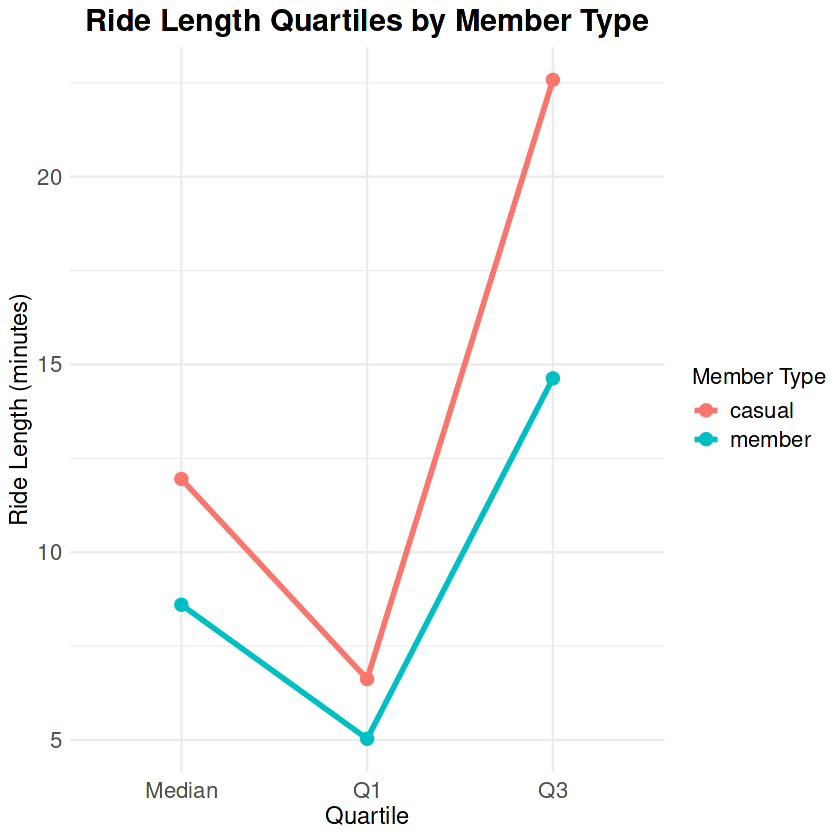

In [12]:
library(ggplot2)

ggplot(quartile_data, aes(x = Quartile, y = Value, group = member_casual, color = member_casual)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  labs(
    title = "Ride Length Quartiles by Member Type",
    x = "Quartile",
    y = "Ride Length (minutes)",
    color = "Member Type"
  ) +
  theme_minimal() +
theme (plot.title = element_text(size = 18, face = "bold", hjust = 0.5),  # center title
    axis.title.x = element_text(size = 14),
    axis.title.y = element_text(size = 14),
    axis.text.x = element_text(size = 13, vjust = 0.7),
    axis.text.y = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.text = element_text(size = 13),
    strip.text = element_text(size = 13, face = "bold"))


This visualization emphasize the trend in higher ride length for casual members 


2. **Ride frequency by time of day**

Now we will measure in which period of day trips are more frequent according to the type of member.

In [13]:


# Ensure StartTime is in proper time format
all_data$StartTime <- hms::as_hms(all_data$StartTime)

# Create a new column called DayPeriod
all_data <- all_data %>%
  mutate(
    TimeOfDay = case_when(
      StartTime < hms::as_hms("06:00:00") ~ "Early Morning",
      StartTime < hms::as_hms("12:00:00") ~ "Morning",
      StartTime < hms::as_hms("18:00:00") ~ "Afternoon",
      TRUE ~ "Night"
    )
  )

In [14]:
all_data %>%
  count(TimeOfDay)


TimeOfDay,n
<chr>,<int>
Afternoon,2708758
Early Morning,225380
Morning,1578248
Night,1568869


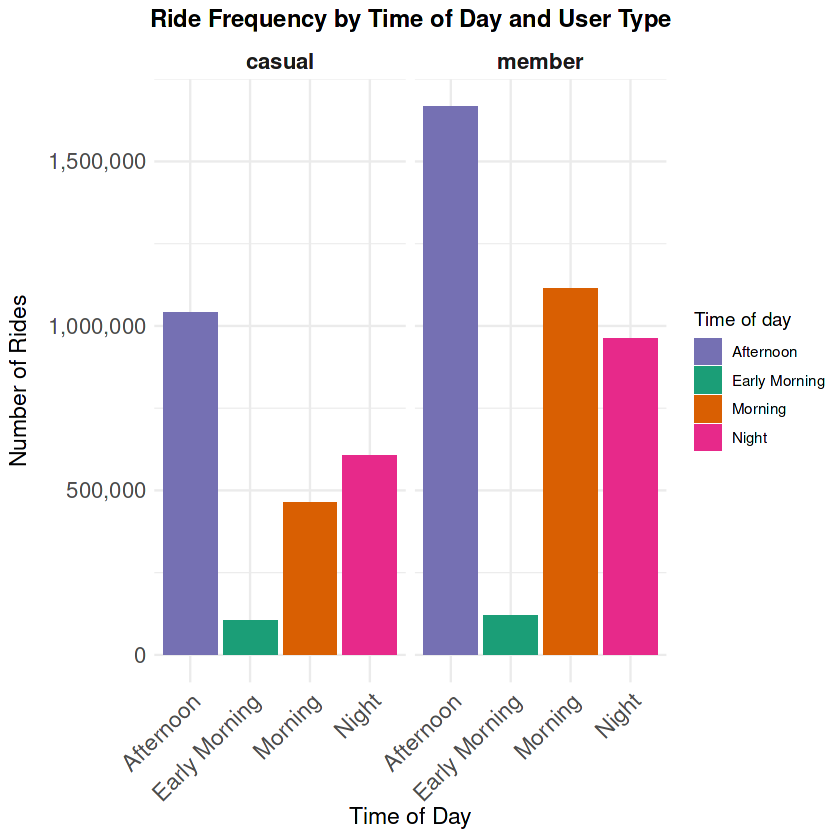

In [15]:
ggplot(data=all_data)+geom_bar(mapping=aes(x=TimeOfDay, fill= TimeOfDay))+
scale_fill_manual(values=c( "Early Morning" = "#1b9e77",
    "Morning" = "#d95f02",
    "Afternoon" = "#7570b3",
    "Night" = "#e7298a"))+
 scale_y_continuous(labels = scales::label_comma()) +
  facet_wrap(~ member_casual)+
labs(title= "Ride Frequency by Time of Day and User Type",
    x = "Time of Day",
    y = "Number of Rides",
    fill= "Time of day")+
theme_minimal() +
theme( axis.text.x = element_text(size = 13.5, angle = 45, vjust = 1,hjust=1),
     axis.text.y= element_text(size= 13) ,
      axis.title.y=element_text(size=13.5,margin=margin(r=11)),
      axis.title.x=element_text(size=13.5,margin=margin(r=10)),
      plot.title=element_text(size=14,face= "bold",hjust=0.5),
     strip.text=element_text(size = 13, face = "bold"))


This chart make clear that for both users the more frequent period of day for rides is in the afternoon. However is visible that casual members prefer rides at night, while annual members prefer in the morning. 


3. **Ride frequency by day of week**

Now I will classify the dates according to the weekday to figure out if casual members prefer make trips in weekends then annual members. But first, I will filter my dataset to exclude unnecessary columns.

In [16]:
all_data.2 <- all_data %>%
select(-StartMinutes,-EndedMinutes,-EndedDate)%>%
rename(Date= StartDate)

In [17]:
all_data.2$DayOfWeek <- weekdays(all_data.2$Date)
##all_data.2 <- all_data.2 %>%
##mutate(DayOfWeek = ifelse(DayOfWeek %in% c("Saturday", "Sunday"), "Weekend", "Weekday"))

In [18]:
all_data.2$DayOfWeek <- factor(all_data.2$DayOfWeek,
                             levels = c("Sunday", "Saturday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"))

In [19]:
all_data.2$DayType <- ifelse(all_data.2$DayOfWeek %in% c("Saturday", "Sunday"), "Weekend", "Weekday")


In [20]:
install.packages("viridis")  # Install
library("viridis")           # Load

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: viridisLite



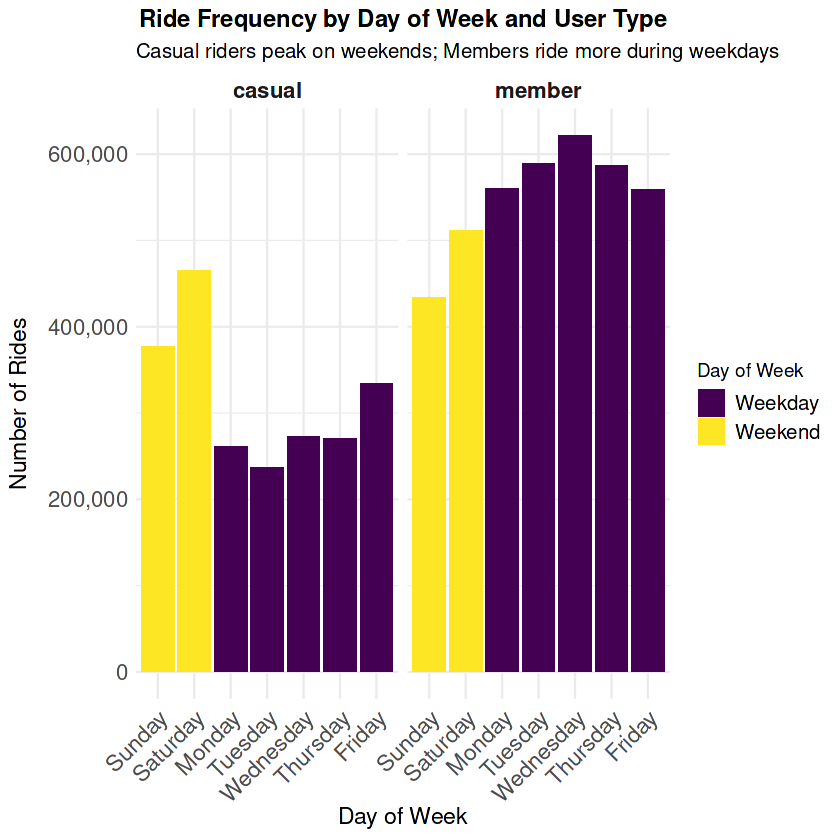

In [21]:
ggplot(data=all_data.2)+geom_bar(mapping=aes(x=DayOfWeek,fill=DayType))+
 scale_fill_viridis(discrete = TRUE)+
scale_y_continuous(labels=scales::label_comma())+
facet_wrap(~member_casual)+
labs(
    title = "Ride Frequency by Day of Week and User Type",
    subtitle = "Casual riders peak on weekends; Members ride more during weekdays",
    x = "Day of Week",
    y = "Number of Rides",
    fill = "Day of Week") +

theme_minimal() +
theme( axis.text.x = element_text(size = 13.5, angle = 45, vjust = 1,hjust=1),
     axis.text.y= element_text(size= 13) ,
      axis.title.y=element_text(size=13.5,margin=margin(r=11)),
      axis.title.x=element_text(size=13.5,margin=margin(r=10)),
      plot.title=element_text(size=14,face= "bold",hjust=0.5),
     strip.text=element_text(size = 13, face = "bold"),
     legend.text = element_text(size = 12),
     plot.subtitle=element_text(size=12))

Looking to this chart we notice a clearly difference between casual and annual members. Casual members tend to use bikes in weekendes, while annual members use bikes more frequent in weekdays. 

4. **Ride frequency by rideable type**

The last difference we can measure between members is the ride frquency by rideable type. Using a plot we will figure out if casual members have a specific preference for some rideable type.  

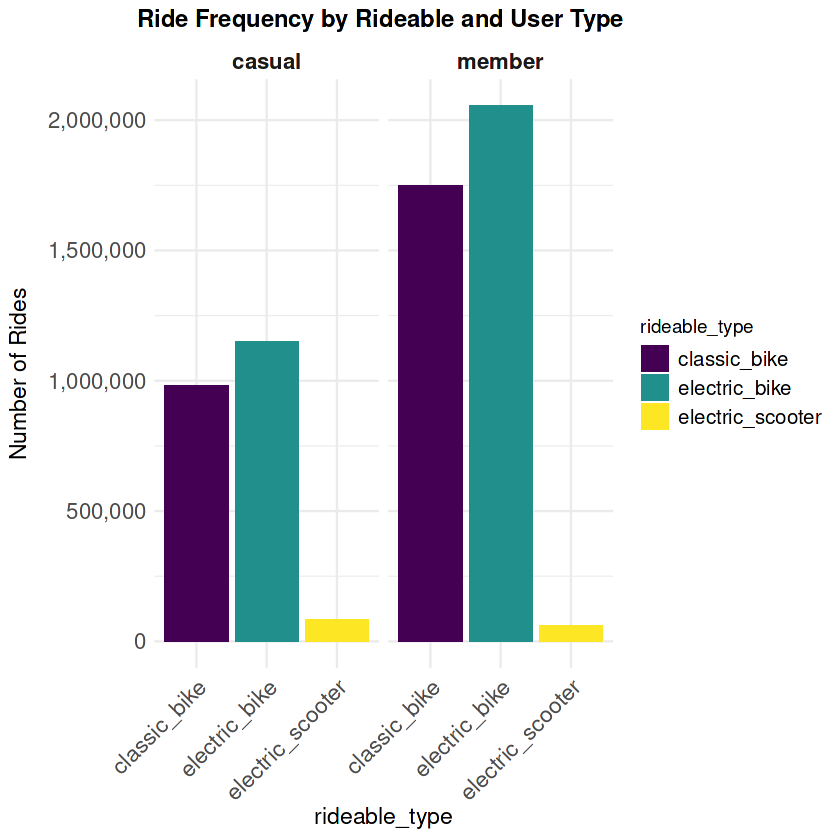

In [22]:
ggplot(data=all_data.2)+geom_bar(mapping=aes(x=rideable_type,fill=rideable_type))+
scale_fill_viridis(discrete = TRUE)+
scale_y_continuous(labels=scales::label_comma())+
facet_wrap(~member_casual)+
theme_minimal()+
labs(title="Ride Frequency by Rideable and User Type ",
    y= "Number of Rides")+
theme( axis.text.x = element_text(size = 13.5, angle = 45, vjust = 1,hjust=1),
     axis.text.y= element_text(size= 13) ,
      axis.title.y=element_text(size=13.5,margin=margin(r=11)),
      axis.title.x=element_text(size=13.5,margin=margin(r=10)),
      plot.title=element_text(size=14,face= "bold",hjust=0.5),
     strip.text=element_text(size = 13, face = "bold"),
     legend.text = element_text(size = 12))



This chart emphasize that eletric bikes are the most popular bike among both types of members,while eletric scooter is not frequently used. 

# Conclusion

Based on the key differences identified between casual riders and annual members, several strategic recommendations can be made to support an effective marketing approach aimed at increasing Cyclistic's annual memberships:

**Offer Discounts Based on Trip Duration**
Since casual riders tend to take longer trips, offering promotional pricing or discounts proportional to ride duration could be an attractive incentive for this group. Such a strategy may encourage them to ride more often and consider the benefits of membership.

**Improve Bike Availability During Peak Hours**
Casual riders primarily use Cyclistic bikes in the afternoon and evening. Ensuring high bike availability during these peak times would enhance their experience. Marketing efforts should highlight this availability and focus on promoting afternoon and evening rides to better connect with the habits of casual users.

**Introduce a Weekend-Focused Membership Option**
The main difference identified between user types is the strong preference of casual riders for biking on weekends, which suggests their usage is primarily for leisure purposes. This indicates that casual riders have different needs compared to annual members. Therefore, creating a new type of annual membership tailored to weekend use could better meet their expectations. Promoting this specialized plan through targeted campaigns could be a key step in converting casual riders into annual members.

**Prioritize Classic and Electric Bikes**
Both user groups show a strong preference for classic and electric bikes, while electric scooter usage is significantly lower. Reducing investment in scooters and focusing on maintaining and expanding the availability of preferred bike types would align better with user demand.

By implementing these recommendations, Cyclistic can more effectively address the preferences of casual riders, thereby increasing the likelihood of converting them into loyal annual members and driving sustainable growth for the company.

